# Exercícios de Regressão Logística e Classificação Binária

José Matheus Gonçalves Rodrigues - 2171 - GEC

#Exercício 1:

A Regressão Logística funciona em duas etapas:


## 1. Parte Linear

Primeiro, o modelo calcula:

$$
z = w_1 x_1 + w_2 x_2 + b
$$

onde:

- $x_1$ e $x_2$ são as entradas (features)  
- $w_1$ e $w_2$ são os pesos  
- $b$ é o bias (ajuste)



## 2. Função Sigmoide

Depois, aplica a função sigmoide:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Isso transforma o valor em uma **probabilidade entre 0 e 1**.


## Tarefa 1

Suponha que o modelo aprendeu:

- $w_1 = 2.0$  
- $w_2 = -1.0$  
- $b = 0.5$

E temos um ponto:

- $x_1 = 1.2$  
- $x_2 = -0.3$


### a) Calcule o valor de $z$

$$
z = w_1 x_1 + w_2 x_2 + b
$$


### b) Calcule a probabilidade

$$
\hat{y} = \frac{1}{1 + e^{-z}}
$$


### c) Classificação final

- Se $\hat{y} > 0.5$ → Classe 1  
- Caso contrário → Classe 0  



## Tarefa 2

Responda com suas próprias palavras:

1. O que representam $w_1$ e $w_2$?  
2. Qual o papel do $b$?  
3. Por que usamos a função sigmoide?

Dica:

- $w$ → importância de cada variável  
- $b$ → ajuste da linha  
- Sigmoide → transforma em probabilidade  

In [4]:
import numpy as np
w1 = 2.0
w2 = -1.0
b = 0.5
x1 = 1.2
x2 = -0.3

z = w1*x1 + w2*x2 + b

y_hat = 1 / (1 + np.exp(-z))

classe = 1 if y_hat > 0.5 else 0
print(f"z = {z:.2f}")
print(f"Probabilidade = {y_hat:.4f}")
print(f"Classe final = {classe}")

z = 3.20
Probabilidade = 0.9608
Classe final = 1


Tarefa 2:

Na regressão logística, o modelo calcula inicialmente uma combinação das entradas (z = w1*x1 + w2*x2 + b).
Os pesos w1 e w2 indicam a influência das variáveis x1 e x2, e a mudança desses pesos impacta diretamente o valor de z.

A constante b funciona como um deslocamento da fronteira de decisão, não dependendo diretamente das variáveis.

Utilizamos a função sigmoide (y) para converter a combinação das entradas (z) em uma probabilidade, permitindo decidir se a classe é 0 ou 1 (classificação binária).



# Exercício 2:

Neste exercício, você vai criar um código semelhante ao exemplo visto em aula para treinar um modelo de **Regressão Logística**.


# Tarefa

Implemente um classificador binário seguindo os seguintes dados:

Crie duas classes:

- Classe 0: centrada em (-2, -2)  
- Classe 1: centrada em (2, 2)  

Use distribuição normal para gerar os pontos.

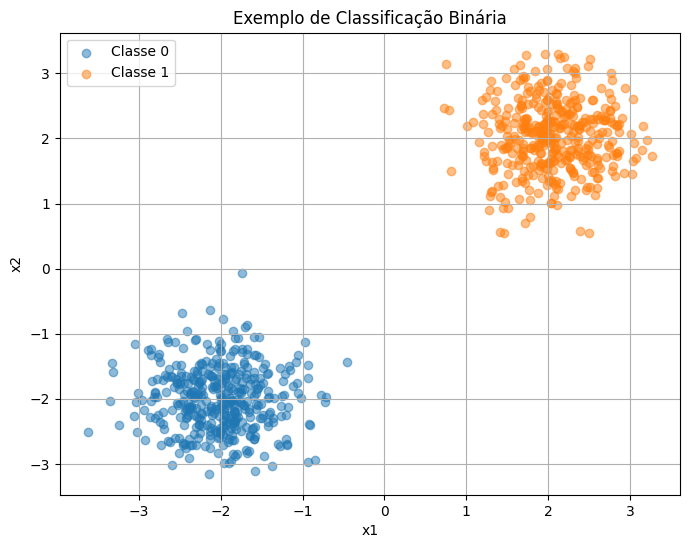

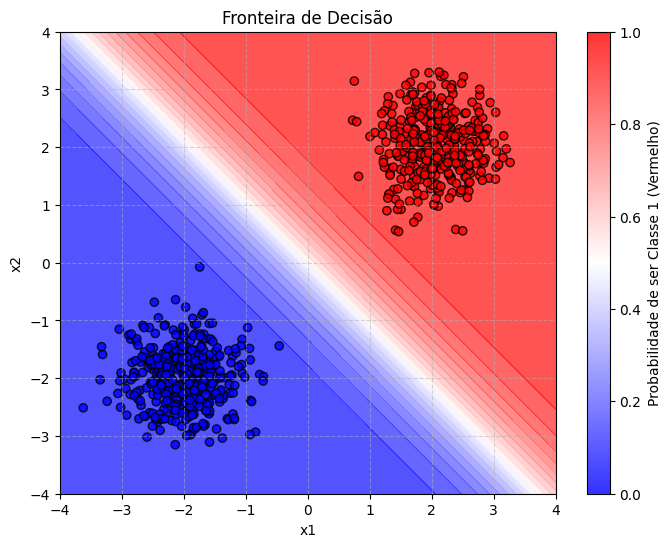

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

np.random.seed(42)

N = 400

# Classe 0
# SEU CÓDIGO AQUI
x0 = np.random.randn(N, 2) * 0.5 + np.array([-2, -2])
y0 = np.zeros(N)
# Classe 1
# SEU CÓDIGO AQUI
x1 = np.random.randn(N, 2) * 0.5 + np.array([2, 2])
y1 = np.ones(N)
# Juntar dados
# SEU CÓDIGO AQUI
X = np.vstack([x0, x1])
Y = np.hstack([y0, y1])
# Separar treino e teste
# SEU CÓDIGO AQUI
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)
# Treinar modelo
# SEU CÓDIGO AQUI
model = LogisticRegression()
model.fit(X_train, y_train)
# Predição
# SEU CÓDIGO AQUI
y_pred = model.predict(X_test)
# Plot dos dados
# SEU CÓDIGO AQUI
plt.figure(figsize=(8,6))

plt.scatter(x0[:,0], x0[:,1], alpha=0.5, label="Classe 0")
plt.scatter(x1[:,0], x1[:,1], alpha=0.5, label="Classe 1")

plt.title("Exemplo de Classificação Binária")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()
# Fronteira de decisão
# SEU CÓDIGO AQUI
# Criando uma malha de pontos para visualizar a fronteira
xx, yy = np.meshgrid(np.linspace(-4, 4, 200),
                     np.linspace(-4, 4, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

# 1. Plotando a fronteira com o mapa de cores Blue-White-Red (0=Azul, 1=Vermelho)
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, probs, levels=20, alpha=0.7, cmap="bwr")

# 2. Plotando os pontos garantindo que a cor do ponto bata com o fundo
# C=Y faz com que 0 seja Azul e 1 seja Vermelho no cmap 'bwr'
plt.scatter(X[:,0], X[:,1], c=Y, edgecolor="k", cmap="bwr", alpha=0.8)

plt.title("Fronteira de Decisão")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="Probabilidade de ser Classe 1 (Vermelho)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Desafio:

Simule um dataset de saúde, onde a probabilidade de risco é dada por uma função logística.

Probabilidade:

$$ p = \frac{1}{1 + e^{-(0.03 \cdot P + 0.02 \cdot C - 10)}} $$

Tarefas
* Simular 700 pacientes.
* Calcular $p$ usando a fórmula acima.
* Gerar a classe $y$.
* Treinar regressão logística.

Acurácia: 0.862
Pesos: [[0.03144329 0.01954376]]
Bias: [-10.24946017]


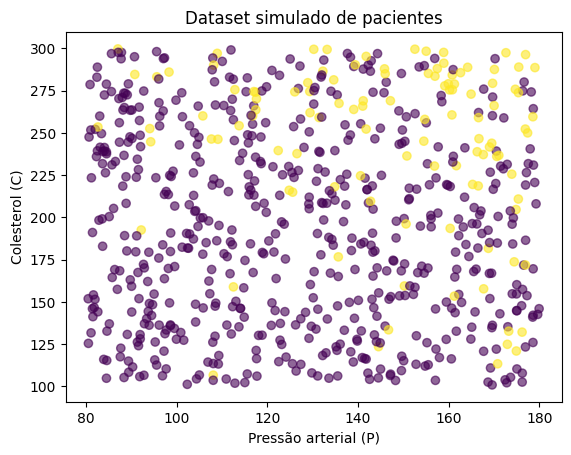

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Simular pacientes
# SEU CÓDIGO AQUI
np.random.seed(42)
np.random.seed(42)
N = 700

P = np.random.uniform(80, 180, N)   #pressão de um ser humano normal
C = np.random.uniform(100, 300, N)  #colesterol de um ser humano normal



# 2. Calcular p
# SEU CÓDIGO AQUI
p = 1 / (1 + np.exp(-(0.03*P + 0.02*C - 10)))

# 3. Criar classes
# SEU CÓDIGO AQUI
y = np.random.binomial(1, p)
X = np.column_stack([P, C])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 4. Treinar modelo
# SEU CÓDIGO AQUI

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = np.mean(y_test == y_pred)
print(f"Acurácia: {acc:.3f}")

print("Pesos:", model.coef_)
print("Bias:", model.intercept_)

plt.scatter(P, C, c=y, alpha=0.6)
plt.xlabel("Pressão arterial (P)")
plt.ylabel("Colesterol (C)")
plt.title("Dataset simulado de pacientes")
plt.show()